<a href="https://colab.research.google.com/github/AmanuelDaget/Military-Aircraft-Recognition-Using-YOLO12/blob/main/Military_Aircraft_detection_from_Satellite_image_using_YOLO12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Military Aircraft Detection from Satellite image Using CNN and YOLO26: by Amanuel D**

**Install libraries**

In [8]:
!pip install ultralytics
!pip install lxml
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.7 MB/s eta 0:00:00


**Import libraries**

In [62]:
import os
import os
import cv2
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xml.etree.ElementTree as ET

from tqdm import tqdm
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import torch
import torch.nn as nn
import torch.optim as optim

from collections import Counter

from torchvision import transforms
from torchvision import datasets
from torchvision import models
from torch.utils.data import DataLoader

from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


**Mount Google Drive**

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


**Copy dataset from Drive**

In [3]:
!cp "/content/drive/MyDrive/Colab Notebooks/Computer Vision and Image Processing/Military_Aircraft_Detection_from_Satellite_image_CV_Project/MAR20.zip" /content/

Unzip the dataset
**bold text**

In [4]:
!unzip -q /content/MAR20.zip -d /content/MAR20

In [6]:
base_path = "/content/MAR20"

print(os.listdir(base_path))

['JPEGImages', 'ImageSets', 'Annotations']


**Define Dataset Paths**

In [55]:
BASE_DIR = "/content/MAR20"

IMAGE_DIR = os.path.join(BASE_DIR, "JPEGImages")

ANNOTATION_DIR = os.path.join(
    BASE_DIR,
    "Annotations",
    "Horizontal Bounding Boxes"
)

**`Read All Image IDs`**

In [56]:
all_image_ids = []

for file in os.listdir(ANNOTATION_DIR):

    if file.endswith('.xml'):

        image_id = file.replace('.xml', '')

        all_image_ids.append(image_id)

print("Total Images:", len(all_image_ids))

Total Images: 3842


**Create Clean Dataset Folders**

In [57]:
os.makedirs(
    '/content/cleaned_dataset/images',
    exist_ok=True
)

os.makedirs(
    '/content/cleaned_dataset/annotations',
    exist_ok=True
)

**Dataset Cleaning**

In [58]:
valid_ids = []
bad_files = []

MIN_BOX_SIZE = 5

for image_id in tqdm(all_image_ids):

    image_path = os.path.join(
        IMAGE_DIR,
        image_id + '.jpg'
    )

    xml_path = os.path.join(
        ANNOTATION_DIR,
        image_id + '.xml'
    )

    # Check file existence
    if not os.path.exists(image_path):
        bad_files.append(image_id)
        continue

    if not os.path.exists(xml_path):
        bad_files.append(image_id)
        continue

    # Check image readability
    image = cv2.imread(image_path)

    if image is None:
        bad_files.append(image_id)
        continue

    # Validate XML
    try:

        root = ET.parse(xml_path).getroot()

        valid_annotation = True

        for obj in root.findall('object'):

            bbox = obj.find('bndbox')

            xmin = int(bbox.find('xmin').text)
            ymin = int(bbox.find('ymin').text)
            xmax = int(bbox.find('xmax').text)
            ymax = int(bbox.find('ymax').text)

            # Invalid boxes
            if xmin >= xmax or ymin >= ymax:
                valid_annotation = False
                break

            # Remove tiny boxes
            if (xmax - xmin) < MIN_BOX_SIZE:
                valid_annotation = False
                break

            if (ymax - ymin) < MIN_BOX_SIZE:
                valid_annotation = False
                break

        if valid_annotation:

            valid_ids.append(image_id)

            shutil.copy(
                image_path,
                '/content/cleaned_dataset/images'
            )

            shutil.copy(
                xml_path,
                '/content/cleaned_dataset/annotations'
            )

        else:
            bad_files.append(image_id)

    except:
        bad_files.append(image_id)

print("Valid Images:", len(valid_ids))
print("Bad Files:", len(set(bad_files)))

100%|██████████| 3842/3842 [00:33<00:00, 113.86it/s]

Valid Images: 3841
Bad Files: 1


**Update Dataset Paths**

In [59]:
IMAGE_DIR = '/content/cleaned_dataset/images'

ANNOTATION_DIR = '/content/cleaned_dataset/annotations'

**Create New 80/20 Split**

In [60]:
train_ids, test_ids = train_test_split(
    valid_ids,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print("Training Images:", len(train_ids))
print("Validation Images:", len(test_ids))

Training Images: 3072
Validation Images: 769


**Analyze Class Distribution**

In [78]:
class_counts = Counter()

for xml_file in os.listdir(ANNOTATION_DIR):

    xml_path = os.path.join(
        ANNOTATION_DIR,
        xml_file
    )

    root = ET.parse(xml_path).getroot()

    for obj in root.findall('object'):

        class_name = obj.find('name').text

        class_counts[class_name] += 1

print(class_counts)

Counter({'A16': 2632, 'A14': 1778, 'A2': 1728, 'A13': 1652, 'A1': 1646, 'A17': 1397, 'A5': 1262, 'A19': 1236, 'A3': 1176, 'A9': 1083, 'A20': 981, 'A8': 944, 'A10': 924, 'A12': 702, 'A7': 679, 'A4': 642, 'A15': 618, 'A11': 507, 'A6': 441, 'A18': 308})


**Plot Class Distribution**

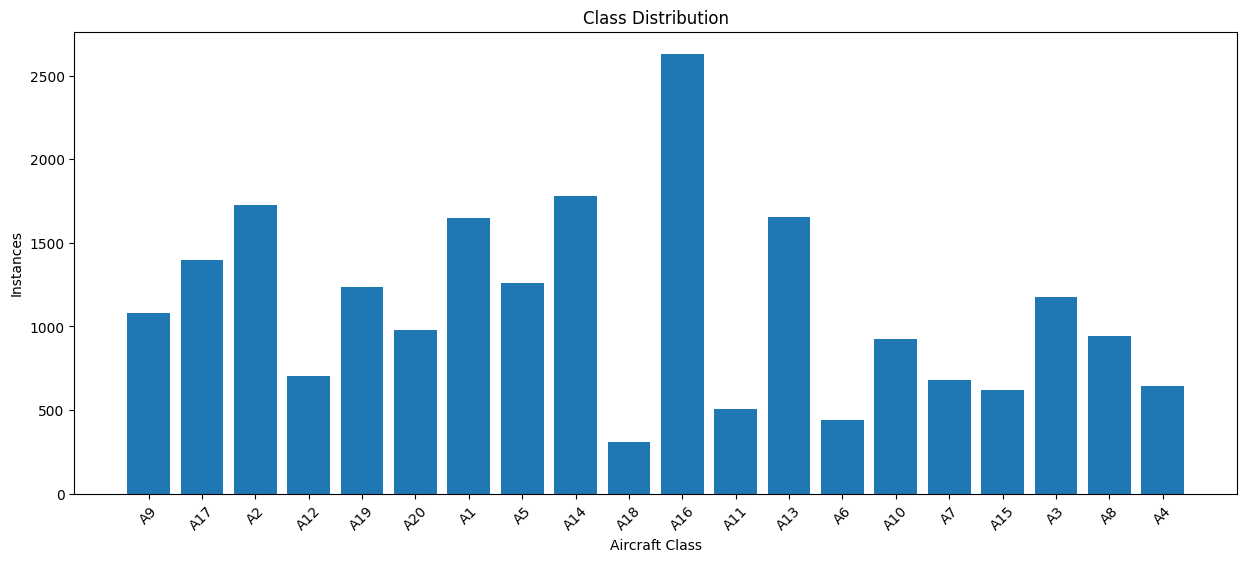

In [64]:
classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure(figsize=(15,6))

plt.bar(classes, counts)

plt.xticks(rotation=45)

plt.xlabel('Aircraft Class')
plt.ylabel('Instances')
plt.title('Class Distribution')

plt.show()

**Visualize Random Samples**

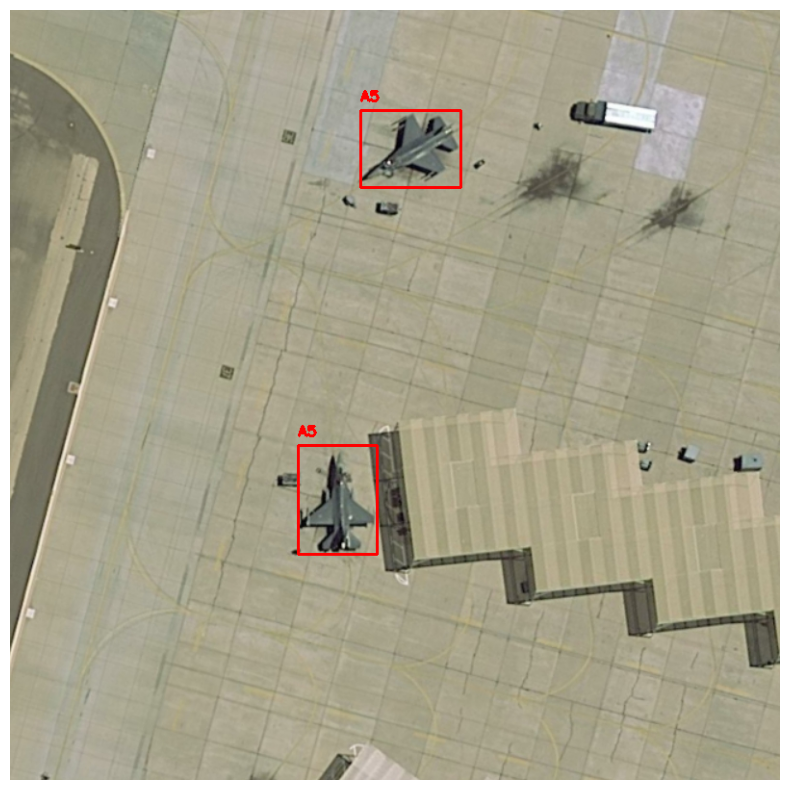

In [65]:
sample_id = random.choice(train_ids)

image_path = os.path.join(
    IMAGE_DIR,
    sample_id + '.jpg'
)

xml_path = os.path.join(
    ANNOTATION_DIR,
    sample_id + '.xml'
)

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

root = ET.parse(xml_path).getroot()

for obj in root.findall('object'):

    class_name = obj.find('name').text

    bbox = obj.find('bndbox')

    xmin = int(bbox.find('xmin').text)
    ymin = int(bbox.find('ymin').text)
    xmax = int(bbox.find('xmax').text)
    ymax = int(bbox.find('ymax').text)

    cv2.rectangle(
        image,
        (xmin, ymin),
        (xmax, ymax),
        (255,0,0),
        2
    )

    cv2.putText(
        image,
        class_name,
        (xmin, ymin-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255,0,0),
        2
    )

plt.figure(figsize=(10,10))
plt.imshow(image)
plt.axis('off')
plt.show()

**Create YOLO Dataset Structure**

In [67]:
os.makedirs(
    '/content/yolo_dataset/images/train',
    exist_ok=True
)

os.makedirs(
    '/content/yolo_dataset/images/val',
    exist_ok=True
)

os.makedirs(
    '/content/yolo_dataset/labels/train',
    exist_ok=True
)

os.makedirs(
    '/content/yolo_dataset/labels/val',
    exist_ok=True
)

**Create Class Mapping**

In [69]:
classes = sorted(list(class_counts.keys()))

class_to_id = {
    cls:i for i, cls in enumerate(classes)
}

id_to_class = {
    i:cls for cls, i in class_to_id.items()
}

print(class_to_id)

{'A1': 0, 'A10': 1, 'A11': 2, 'A12': 3, 'A13': 4, 'A14': 5, 'A15': 6, 'A16': 7, 'A17': 8, 'A18': 9, 'A19': 10, 'A2': 11, 'A20': 12, 'A3': 13, 'A4': 14, 'A5': 15, 'A6': 16, 'A7': 17, 'A8': 18, 'A9': 19}


**Convert XML to YOLO Format**

In [71]:
def convert_to_yolo(size, box):

    w, h = size

    xmin, ymin, xmax, ymax = box

    x_center = ((xmin + xmax) / 2) / w
    y_center = ((ymin + ymax) / 2) / h

    width = (xmax - xmin) / w
    height = (ymax - ymin) / h

    return (
        x_center,
        y_center,
        width,
        height
    )

Convert Entire Dataset

In [79]:
def process_dataset(image_ids, split='train'):

    for image_id in tqdm(image_ids):

        image_file = image_id + '.jpg'
        xml_file = image_id + '.xml'

        image_path = os.path.join(
            IMAGE_DIR,
            image_file
        )

        xml_path = os.path.join(
            ANNOTATION_DIR,
            xml_file
        )

        image = cv2.imread(image_path)

        h, w, _ = image.shape

        label_lines = []

        root = ET.parse(xml_path).getroot()

        for obj in root.findall('object'):

            class_name = obj.find('name').text

            class_id = class_to_id[class_name]

            bbox = obj.find('bndbox')

            xmin = int(bbox.find('xmin').text)
            ymin = int(bbox.find('ymin').text)
            xmax = int(bbox.find('xmax').text)
            ymax = int(bbox.find('ymax').text)

            yolo_box = convert_to_yolo(
                (w,h),
                (xmin,ymin,xmax,ymax)
            )

            label_line = (
                f"{class_id} " +
                " ".join(map(str, yolo_box))
            )

            label_lines.append(label_line)

        shutil.copy(
            image_path,
            f'/content/yolo_dataset/images/{split}/{image_file}'
        )

        with open(
            f'/content/yolo_dataset/labels/{split}/{image_id}.txt',
            'w'
        ) as f:

            f.write('\n'.join(label_lines))

**Process Train and Validation Sets**

In [80]:
process_dataset(train_ids, split='train')

process_dataset(test_ids, split='val')

100%|██████████| 769/769 [00:07<00:00, 99.44it/s] 


**Create YOLO YAML File**

In [81]:
yaml_content = '''
path: /content/yolo_dataset

train: images/train
val: images/val

names:
'''

for i, cls in enumerate(classes):

    yaml_content += f'  {i}: {cls}\\n'

with open(
    '/content/yolo_dataset/dataset.yaml',
    'w'
) as f:

    f.write(yaml_content)

Load YOLO12 Model

In [82]:
model = YOLO('yolo12n.pt')

**Train YOLO12**

In [ ]:
yaml_content = '''
path: /content/yolo_dataset

train: images/train
val: images/val

names:
'''

for i, cls in enumerate(classes):

    yaml_content += f'  {i}: {cls}\n'

with open(
    '/content/yolo_dataset/dataset.yaml',
    'w'
) as f:

    f.write(yaml_content)


model.train(
    data='/content/yolo_dataset/dataset.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    patience=20,
    optimizer='AdamW',
    lr0=0.001,
    pretrained=True,
    cache=True,
    amp=True,

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    degrees=10,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.2
)

Ultralytics 8.4.49 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/dataset.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience